In [2]:
import sys

assert sys.version_info >= (3, 7)

In [3]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [6]:
import numpy as np  # Library for numerical operations and working with arrays
import matplotlib.pyplot as plt  # Library for creating static, animated, and interactive visualizations

from sklearn.model_selection import train_test_split  # Function to split datasets into training and testing sets
from sklearn.preprocessing import StandardScaler  # Scaler for standardizing features by removing the mean and scaling to unit variance
from sklearn.model_selection import cross_val_score  # Function to evaluate a model using cross-validation
from sklearn.model_selection import GridSearchCV  # Function to perform an exhaustive search over specified parameter values for an estimator

from sklearn.datasets import fetch_openml  # Function to fetch datasets from OpenML, such as the MNIST dataset
from sklearn.linear_model import SGDClassifier  # Stochastic Gradient Descent classifier for training linear models
from sklearn.metrics import confusion_matrix, accuracy_score  # Functions to compute evaluation metrics for classification models

     

In [1]:
import numpy as np
import keras
from keras.datasets import mnist as keras_mnist


(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras_mnist.load_data()

X = np.concatenate((X_train_raw, X_test_raw), axis=0).reshape(-1, 28 * 28)
y = np.concatenate((y_train_raw, y_test_raw), axis=0).astype(str)


class MNISTData:
    def __init__(self, data, target):
        self.data = data
        self.target = target
        self.DESCR = "MNIST dataset loaded via Keras workaround."
    def keys(self):
        return ['data', 'target', 'DESCR']

# Create the object the rest of the lab is looking for
mnist = MNISTData(X, y)

print("Workaround complete. Data loaded successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Workaround complete. Data loaded successfully!


In [2]:
print(mnist.DESCR)

MNIST dataset loaded via Keras workaround.


In [3]:
mnist.keys()  #we only use data and target in this notebook

['data', 'target', 'DESCR']

In [4]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784), dtype=uint8)

In [5]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype='<U3')

In [6]:
# Display the shape of the data and labels
print(X.shape, y.shape)

(70000, 784) (70000,)


NameError: name 'save_fig' is not defined

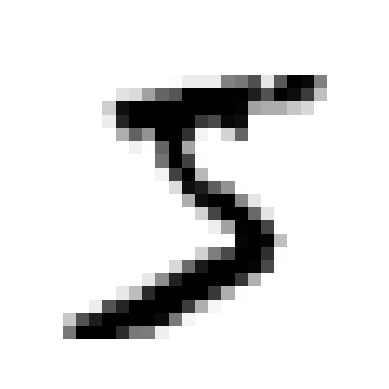

In [7]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary") # to get a grayscale color map where 0 is white and 255 is black
    plt.axis("off")

some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()

In [8]:
print("The first digit in the Data set is: ", y[0]) # check in the label dataset

The first digit in the Data set is:  5


NameError: name 'save_fig' is not defined

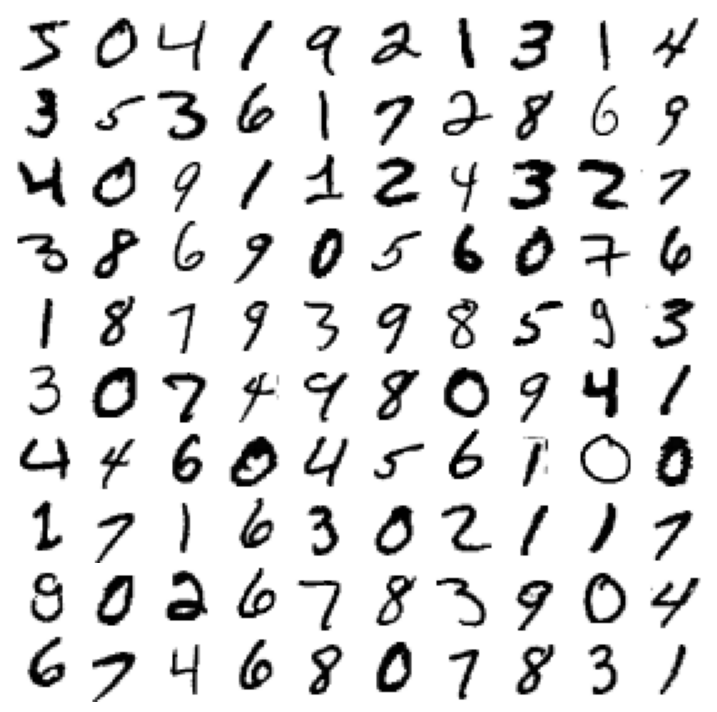

In [9]:
# This cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [11]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [12]:
# Import the SGDClassifier from Scikit-Learn's linear model module
from sklearn.linear_model import SGDClassifier

# Create an instance of the SGDClassifier with a specified random state for reproducibility
# The random state ensures that the results are consistent across different runs
sgd_clf = SGDClassifier(random_state=42)


# Fit the SGDClassifier to the training data
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


NameError: name 'save_fig' is not defined

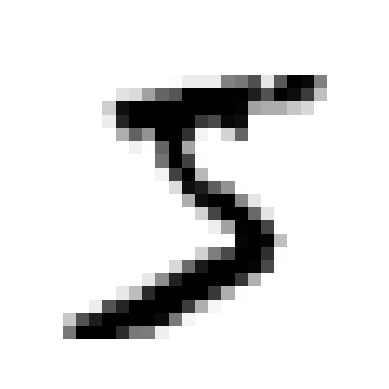

In [13]:
some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()

In [14]:
sgd_clf.predict([some_digit])

array([ True])

NameError: name 'save_fig' is not defined

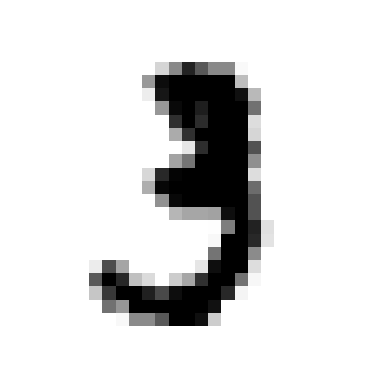

In [15]:
some_digit = X[10] # display 10th didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()

In [16]:
sgd_clf.predict([some_digit])

array([False])

In [17]:
# Examples of digits from the dataset
some_digits = X[:5]

# Make predictions on the multiple examples
predictions = sgd_clf.predict(some_digits)

# Display the predictions
print("Predictions for some_digits:", predictions)

Predictions for some_digits: [ True False False False False]


In [18]:
from sklearn.model_selection import cross_val_score # Import the cross_val_score function from Scikit-Learn


# Perform 3-fold cross-validation on the SGD classifier
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'scoring="accuracy"' specifies that we want to calculate the accuracy score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

# Display the cross-validation accuracy scores
#print("Cross-validation accuracy:", cross_val_score)
     

array([0.95035, 0.96035, 0.9604 ])

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is not
                                       # already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))
     

0.95035
0.96035
0.9604


In [20]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # it prints False: which means no 5s detected

False


In [21]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [22]:
# Import cross_val_predict function from Scikit-Learn
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions for the training set
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [23]:
# Import confusion_matrix function from Scikit-Learn
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix to evaluate the classifier's performance
# 'y_train_5' are the actual labels
# 'y_train_pred' are the predicted labels from cross-validation
cm = confusion_matrix(y_train_5, y_train_pred)
#cm

In [24]:
# Display the confusion matrix
print(cm)

[[53892   687]
 [ 1891  3530]]


In [25]:
# Pretend we reached perfection by setting the predicted labels equal to the true labels
y_train_perfect_predictions = y_train_5

# Compute the confusion matrix with perfect predictions
# The confusion matrix should show all true positives and true negatives, with no false positives or false negatives
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [26]:
# Import precision_score and recall_score from Scikit-Learn
from sklearn.metrics import precision_score, recall_score


# Compute the precision score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
precision = precision_score(y_train_5, y_train_pred)  # # Calculate precision: TP / (FP + TP) that is == 3530 / (687 + 3530)
print("Precision:", precision)

Precision: 0.8370879772350012


In [27]:
#To compute the precision manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[0, 1]' is FP
precision_manual = cm[1, 1] / (cm[0, 1] + cm[1, 1])
print("Manual precision calculation:", precision_manual) # manual precision calucltion from the confusion matrix
     

Manual precision calculation: 0.8370879772350012


In [28]:
# Compute the recall score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
recall = recall_score(y_train_5, y_train_pred)  # Calculate recall: TP / (FN + TP)
print("Recall:", recall)

Recall: 0.6511713705958311


In [29]:
# To compute the recall manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[1, 0]' is FN
recall_manual = cm[1, 1] / (cm[1, 0] + cm[1, 1])
print("Manual recall calculation:", recall_manual) # manual recall calucltion from the confusion matrix
  

Manual recall calculation: 0.6511713705958311


In [30]:
# Import the f1_score function from Scikit-Learn
from sklearn.metrics import f1_score

# Compute the F1 Score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
f1 = f1_score(y_train_5, y_train_pred)  # Calculate the F1 Score using the precision and recall
print("F1 Score:", f1)

F1 Score: 0.7325171197343847


In [31]:
# To compute the F1 Score manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[1, 0]' is FN, 'cm[0, 1]' is FP
# extra code – this cell also computes the f1 score
f1_manual = cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)
print("Manual F1 Score calculation:", f1_manual)

Manual F1 Score calculation: 0.7325171197343847


In [32]:
from sklearn.metrics import classification_report

# Confusion Matrix
print("Confusion Matrix:")
print(cm)

# Classification Report
class_report = classification_report(y_train_5, y_train_pred)
print("Classification Report:")
print(class_report)

Confusion Matrix:
[[53892   687]
 [ 1891  3530]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



In [33]:
some_digit = X[0] # check for 1st didgit in the dataset, please feel free to check for other digits as well

# Get the decision scores for a single example
# 'sgd_clf' is the trained SGD classifier
# 'decision_function' returns the distance of the samples to the decision boundary
y_scores = sgd_clf.decision_function([some_digit]) #
print("Decision Scores:", y_scores)
     

Decision Scores: [2164.22030239]


In [34]:
# Apply a decision threshold of 0
# Predict whether 'some_digit' is a positive class (True) or not (False)
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print("Digit prediction based on Decision Score threshold:", y_some_digit_pred)

Digit prediction based on Decision Score threshold: [ True]


In [35]:
# Shows that y_scores > 0 produces the same result as
#              calling predict()
y_scores > 0
     

array([ True])

In [36]:
# Apply a decision threshold of 3000
# Predict whether 'some_digit' is a positive class (True) or not (False)
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [37]:
# Perform cross-validation to obtain the decision scores for each instance in the training set
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix for the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'method="decision_function"' specifies that we want to get the decision scores instead of class labels
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

# 'y_scores' will contain the decision scores for each instance in the training set
print(y_scores)  # Example output: array([1200.5, -500.2, 800.3, ...])

[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


In [38]:
# Import precision_recall_curve from Scikit-Learn
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall for different threshold values
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores' are the decision scores obtained from the classifier
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)


In [39]:
print("Current Threshold is set:", threshold)

Current Threshold is set: 3000


NameError: name 'save_fig' is not defined

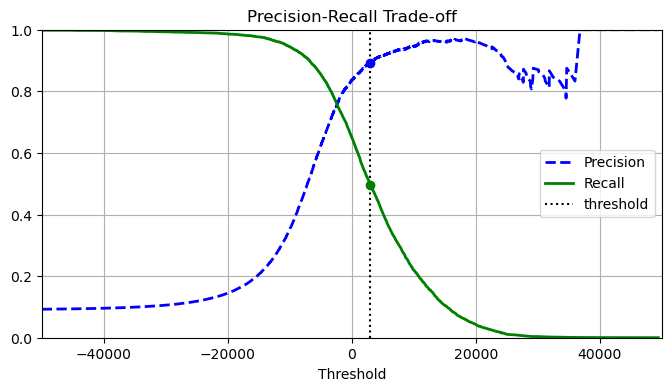

In [40]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
save_fig("precision_recall_vs_threshold_plot")

plt.show()
     

NameError: name 'save_fig' is not defined

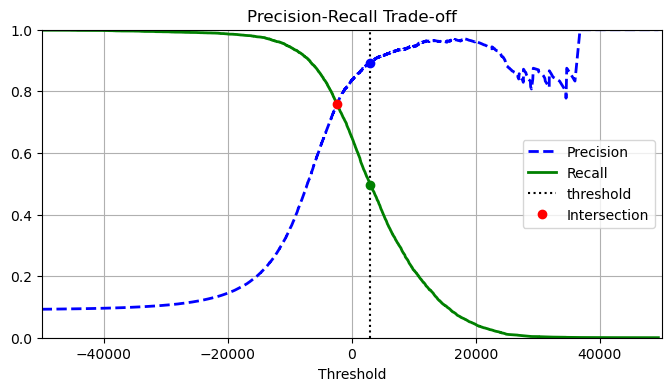

In [41]:
# Highlight the Intersection Point of Precision and Recall


# Find the index where precision and recall are closest to each other
diff = np.abs(precisions - recalls)
min_diff_index = np.argmin(diff)


plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.plot(thresholds[min_diff_index], precisions[min_diff_index], "ro", label="Intersection") # Highlight the intersection point
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
save_fig("precision_recall_vs_threshold_plot")

plt.show()
     

NameError: name 'save_fig' is not defined

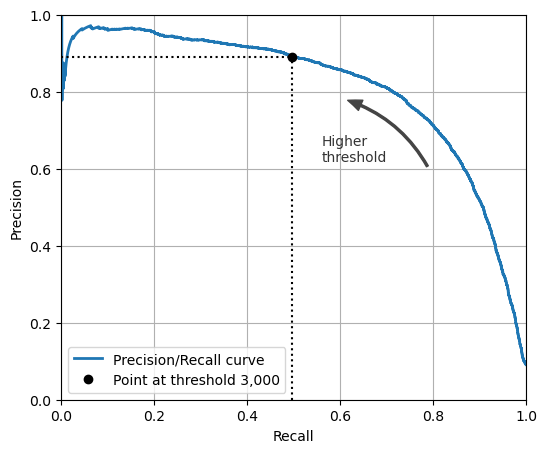

In [42]:
import matplotlib.patches as patches  # For the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

In [43]:
indices_above_90 = np.where(precisions[:len(thresholds)] >= 0.90)[0]

if len(indices_above_90) > 0:
    # Get the first index where precision is >= 0.90
    idx_for_90_precision = indices_above_90[0]
else:
    # If no precision >= 0.90 is found, select the last valid index
    # This is a fallback to prevent IndexError if no threshold meets the criteria
    idx_for_90_precision = len(thresholds) - 1

# Ensure the index is within bounds, especially for edge cases
idx_for_90_precision = min(idx_for_90_precision, len(thresholds) - 1)
idx_for_90_precision = max(idx_for_90_precision, 0)

threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.019499143955)

In [44]:

y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [45]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [46]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

In [47]:
from sklearn.metrics import roc_curve # Import roc_curve function from Scikit-Learn


# Calculate the ROC curve
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores' are the decision scores obtained from the classifier
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

NameError: name 'save_fig' is not defined

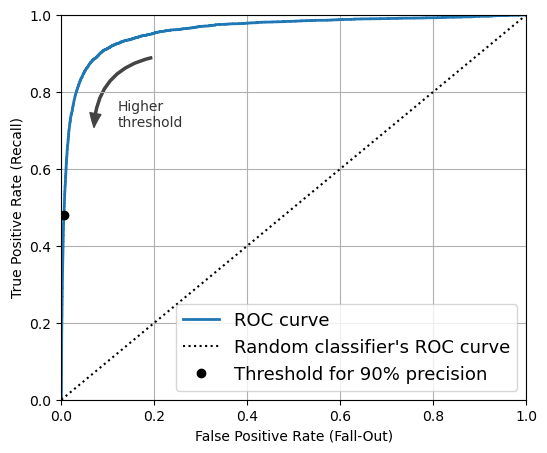

In [48]:
# Find the index of the threshold that gives 90% precision
# 'thresholds' contains the threshold values used to calculate fpr and tpr
# 'threshold_for_90_precision' is a predefined threshold that corresponds to 90% precision
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()

In [49]:
from sklearn.metrics import roc_auc_score # Import the roc_auc_score function from Scikit-Learn

# Calculate the AUC-ROC score
auc_roc= roc_auc_score(y_train_5, y_scores)

# Display the AUC-ROC score
print("AUC-ROC Score:", auc_roc)
     

AUC-ROC Score: 0.9604938554008616


In [50]:
from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier from Scikit-Learn

# Create an instance of the Random Forest Classifier
forest_clf = RandomForestClassifier(random_state=42)

In [51]:
# Perform cross-validation to obtain probability predictions for each instance in the training set
# 'forest_clf' is the Random Forest classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'method="predict_proba"' specifies that we want to get the probability predictions instead of class labels
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")
     

In [54]:
# Display the first two probability predictions
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [55]:
y_scores_forest = y_probas_forest[:, 1]

# Calculate precision and recall for different threshold values
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores_forest' are the scores (probabilities) for the positive class
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)
     

In [56]:
print("Precision Forest=", precisions_forest)
print("Recall Forest=", recalls_forest)
print("Threshold Forest=", thresholds_forest)

Precision Forest= [0.09035    0.15601796 0.21697018 0.2782198  0.3359375  0.39168474
 0.4434341  0.49221099 0.53883011 0.58103448 0.62384152 0.65814579
 0.69354839 0.72090213 0.74856904 0.77310803 0.79370733 0.81468478
 0.83029737 0.84566529 0.8605178  0.87232994 0.88209825 0.89121268
 0.90208833 0.90986159 0.9178634  0.92464178 0.93120086 0.93672255
 0.94127273 0.94605505 0.95223107 0.95618941 0.95927941 0.96257089
 0.96431961 0.96689629 0.96939365 0.97113522 0.97292032 0.975495
 0.97634069 0.9787572  0.98101519 0.98323571 0.98412375 0.98566455
 0.98719273 0.98773389 0.98974681 0.99050833 0.99129327 0.99186644
 0.99180858 0.99259582 0.99340804 0.99378606 0.99440841 0.99458239
 0.99474526 0.99514451 0.99555659 0.99622997 0.99618594 0.99638031
 0.9965661  0.99652605 0.99672462 0.99692938 0.99688393 0.99762031
 0.9981203  0.99809004 0.99832496 0.99828816 0.99825581 0.99821694
 0.99847793 0.99843309 0.99903038 0.99900498 0.99897119 0.99893692
 0.9989011  0.9996173  1.         1.         1

NameError: name 'save_fig' is not defined

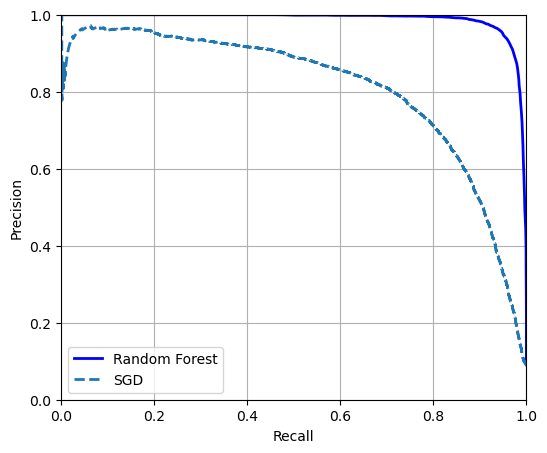

In [57]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("pr_curve_comparison_plot")

plt.show()

In [58]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # positive proba ≥ 50%
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [59]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [60]:
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [61]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

In [62]:
#For class report

# Classification Report SGD
#class_report_SGD = classification_report(y_train_5, y_train_pred)
#print("Classification Report of SGD:")
#print(class_report_SGD)


# Classification Report SGD
class_report_forest = classification_report(y_train_5, y_train_pred_forest)
print("Classification Report of Random Fdrest:")
print(class_report_forest)

Classification Report of Random Fdrest:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99     54579
        True       0.99      0.87      0.93      5421

    accuracy                           0.99     60000
   macro avg       0.99      0.94      0.96     60000
weighted avg       0.99      0.99      0.99     60000

